# Question 1

Consider all parameter values (except t) are fixed and create an interpolator with respect to time t.
You use the original grid for the interpolation.

t = np.linspace(0, 1, 100)
When not varied we will fix the values to a=0.1, b=−0.13, c=9

This means a,b,c are fixed so we only have t as a variable. Input t -> goes into function f -> comes out with f(t) value

## Notes:
- Interpolation is to fill in the gaps, the more granular we go, we the more points we interpolate for a smoother graph (in theory).
- Interpolating the graph at the exact same linspace (0,1,100) would give us the same points, as we constructed it with f anyways.
- The learning objective is to understand that a coarse (wide) grid could lead to a bad approximation.

In [7]:
import numpy as np
from ipywidgets import interactive
import ipywidgets as widgets
import matplotlib.pyplot as plt

def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

def plot_with_parameters(a, b, c):
    # Define time range
    t = np.linspace(0, 1, 100)

    # Calculate f(t) for these parameters
    f_values = f(t, a, b, c)

    # Plot the function
    plt.figure(figsize=(10, 6))
    plt.plot(t, f_values, label=r'$f(t; a, b, c)$', color='blue')
    plt.xlabel('Time $t$')
    plt.ylabel(r'$f(t)$')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.legend()
    plt.grid(True)
    plt.show()

# Create interactive widget
interactive_plot = interactive(
    plot_with_parameters,
    a=widgets.FloatSlider(min=0, max=1, step=0.01, value=0.1),
    b=widgets.FloatSlider(min=-0.5, max=0.5, step=0.01, value=-0.13),
    c=widgets.FloatSlider(min=5, max=10, step=0.1, value=9)
)

display(interactive_plot)

interactive(children=(FloatSlider(value=0.1, description='a', max=1.0, step=0.01), FloatSlider(value=-0.13, de…

In [ ]:
xyz = 5
print(f"value : {xyz}") #Function string
print(r"123\n456") #Raw string, interprets the string literally as you entered it
print("123\n456")
print(r"$f(t; a.bc$") #$ tells Python we are using math inline

print(2 * [1,3]) #Doubles the array with Python built in array
print(2 * np.array([1,3]))  #Multiplies the value with Numpy array


value : 5
123\n456
123
456
$f(t; a.bc$
[1, 3, 1, 3]
[2 6]


# Question 2 and 3

## Notes:
- f_interp is just the function just like f. It requires feeding of the linespace (or our t points)
- Therefore, we assign a new variable that is an array that takes f_interp and feeds in t_interp t points.
- The points are pretty much on top of each other, but why?
    - 100 points between 0 and 1 is very compact and dense.
    - Our interpolation would always have given almost true because its so small and accurate in such fine spaces.
    - This is the benefits of linear interpolation selection in SciPy, linear is almost spot on when the points are dense and the function is smooth.
- The intution is unclear when the grid is finer. If we had a coarse graph, so the blue dots are 1/10, then we see that the interpolation is kinkier, less smooth whilst we see the true values.

The intuition (coarse grid):
- The actual f function defined as np.sqrt
    - t = our time where we want to evaluate f at. if linspace (0,1,10) then t = 0.1,0.2,0.3
    - f_values = the corresponding output when we input the above t points into the f function

- The interpolator using SciPy (finer grid):
    - We know go onto a finer grid and interpolate using the coarse grid points
    - Between each of the t points = 0.1,0.2,0.3, it draws a linear straight line segment
    - For example, on the finer grid we have t_fine value of 0.010101. We find the coarse point before and after it which are 0 and 0.1111 and they had a f value of 0.5 and 0.7576.
    - We use t_fine = 0.010101, left_t = 0, right_t = 0.1111, left_f = 0.5 and right_f = 0.7576 into the interpolation formula to give us an interpolated value for when t_fine = 0.10101 which is f_pred = 0.523425 whilst f_true = 0.528644

## Class Notes

1. Good coding practise is to add space between operators and variables. t = np.linspace... NOT t=np.linespace...
2. Local and Global variables - Python always priortises local variables
3. `interp1d` is a Python Class. Some Python classes have a special object:
F_interp_t(t_new) == F_interp_t.__call__(t_new)

In [ ]:
xyz = 5
def printval(xyz):
    print(xyz)

printval(8) #Local
printval(xyz) #Global

8
5


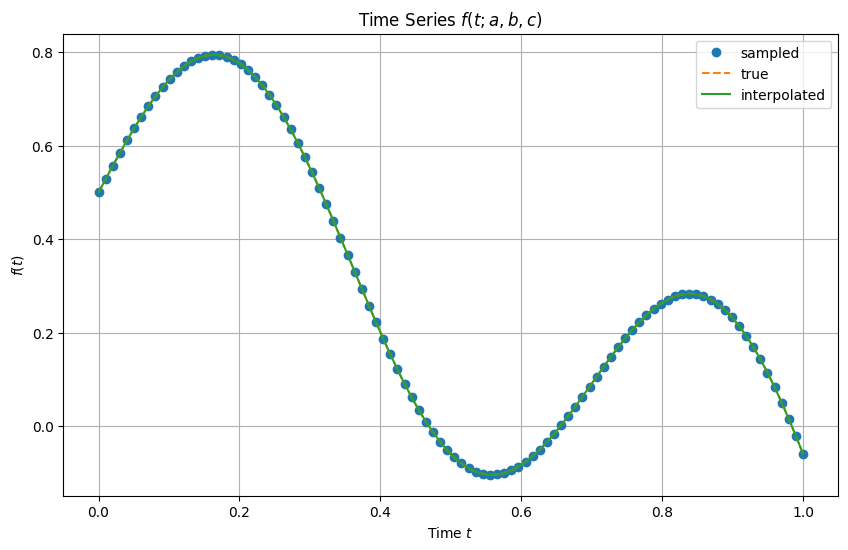

In [21]:
import numpy as np
from scipy.interpolate import interp1d

def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

# Example usage
# Define parameters
a = 0.1
b = -0.13
c = 9

# This is the coarse (wide) gapped linespace for t 
t = np.linspace(0, 1, 100) # time goes from 0 to 1 in increments of 1/100
f_values = f(t, a, b, c) # the f values 
# This is the interpolated values from the same linespace
f_interp = interp1d(t, f_values, kind="linear")

# This is the finer gapped linespace for t
t_fine = np.linspace(0, 1, 1001) # time goes from 0 to 1 in incremenets of 1/1001
# This is the interpolated values against the true
f_pred = f_interp(t_fine)       # interpolated values
f_true = f(t_fine, a, b, c)     # true function

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, 'o', label='sampled')
plt.plot(t_fine, f_true, '--', label='true')
plt.plot(t_fine, f_pred, label='interpolated')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()

Below was my understanding for the interpolation :)

The values of t for gaps 10: [0.         0.11111111 0.22222222 0.33333333 0.44444444 0.55555556
 0.66666667 0.77777778 0.88888889 1.        ]
The values of f for gaps 10: [ 0.5         0.75767304  0.74739794  0.439546    0.06158081 -0.10411627
  0.02126044  0.23748279  0.24843387 -0.05965754]
The values of f_pred for t_fine gaps 1001: [(np.float64(0.0), np.float64(0.5)), (np.float64(0.010101010101010102), np.float64(0.5234248219945477)), (np.float64(0.020202020202020204), np.float64(0.5468496439890953)), (np.float64(0.030303030303030304), np.float64(0.570274465983643)), (np.float64(0.04040404040404041), np.float64(0.5936992879781906)), (np.float64(0.05050505050505051), np.float64(0.6171241099727384)), (np.float64(0.06060606060606061), np.float64(0.640548931967286)), (np.float64(0.07070707070707072), np.float64(0.6639737539618337)), (np.float64(0.08080808080808081), np.float64(0.6873985759563813)), (np.float64(0.09090909090909091), np.float64(0.710823397950929)), (np.float64(0.101010101

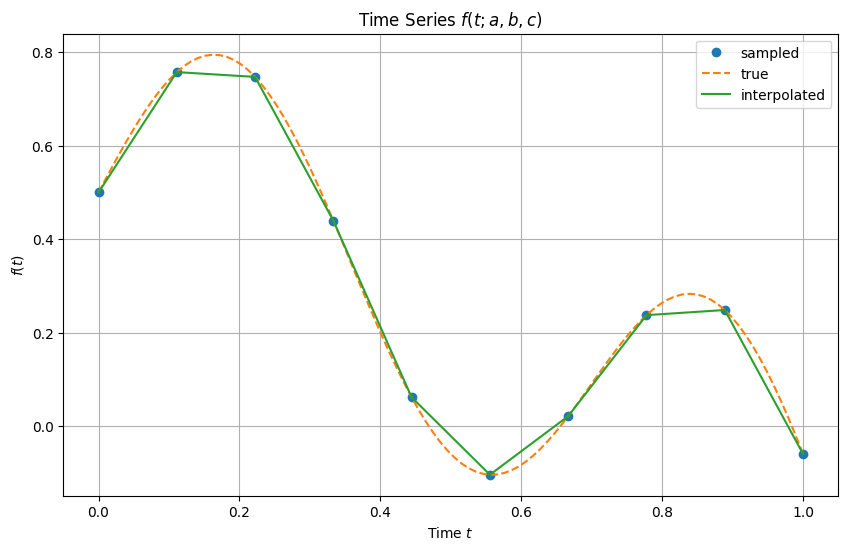

In [ ]:
import numpy as np
from scipy.interpolate import interp1d

def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

# Example usage
# Define parameters
a = 0.1
b = -0.13
c = 9

# This is the coarse (wide) gapped linespace for t 
t = np.linspace(0, 1, 10) # time goes from 0 to 1 in increments of 1/100
f_values = f(t, a, b, c) # the f values 
# This is the interpolated values from the same linespace
f_interp = interp1d(t, f_values, kind="linear")

# This is the finer gapped linespace for t
t_fine = np.linspace(0, 1, 100) # time goes from 0 to 1 in incremenets of 1/1001
# This is the interpolated values against the true
f_pred = f_interp(t_fine)       # interpolated values
f_true = f(t_fine, a, b, c)     # true function

# Plot the function
plt.figure(figsize=(10, 6))
plt.plot(t, f_values, 'o', label='sampled')
plt.plot(t_fine, f_true, '--', label='true')
plt.plot(t_fine, f_pred, label='interpolated')
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import pandas as pd
# Find left/right coarse neighbours for each fine point
left_indices = np.searchsorted(t, t_fine, side='right') - 1
right_indices = np.searchsorted(t, t_fine, side='left')

# Clip indices to keep them in valid range
left_indices = np.clip(left_indices, 0, len(t)-1)
right_indices = np.clip(right_indices, 0, len(t)-1)

# Build the table
df_compare = pd.DataFrame({
    "t_fine": t_fine,
    "f_interpolated": f_pred,
    "f_true": f_true,
    "abs_error": np.abs(f_true - f_pred),
    "t_left": t[left_indices],
    "f_left": f_values[left_indices],
    "t_right": t[right_indices],
    "f_right": f_values[right_indices],
})

# Show first 20 rows
df_compare.head(20)

,t_fine,f_interpolated,f_true,abs_error,t_left,f_left,t_right,f_right
0,0.000000,0.500000,0.500000,0.000000,0.000000,0.500000,0.000000,0.500000
1,0.010101,0.523425,0.528644,0.005219,0.000000,0.500000,0.111111,0.757673
2,0.020202,0.546850,0.556922,0.010072,0.000000,0.500000,0.111111,0.757673
3,0.030303,0.570274,0.584597,0.014323,0.000000,0.500000,0.111111,0.757673
4,0.040404,0.593699,0.611435,0.017736,0.000000,0.500000,0.111111,0.757673
5,0.050505,0.617124,0.637207,0.020083,0.000000,0.500000,0.111111,0.757673
6,0.060606,0.640549,0.661690,0.021141,0.000000,0.500000,0.111111,0.757673
7,0.070707,0.663974,0.684670,0.020697,0.000000,0.500000,0.111111,0.757673
8,0.080808,0.687399,0.705944,0.018545,0.000000,0.500000,0.111111,0.757673
9,0.090909,0.710823,0.725318,0.014495,0.000000,0.500000,0.111111,0.757673


# Question 4

## Notes:
The question is asking us to work out the ratio between the interpolated values and true values across the grid.
This is f_pred / f_true = ratio.
- We expect a perfect interpolation to be equal to 1.
- An imperfect interpolation to be not equal to 1.

Initially, I worked out the ratio by doing f_pred/f_true, which is the actual ratio but it gave some weird graph. The lecturer used the **percent relative error** which is 100 * percentage change basically. The reaosn why, because relative error is more interpretable, the original ratio was so weird and you cannot make any out anything useful from that chart.
- **Percent relative error = 100 * (pred - true) / true**
- The more finer the grid -> the smaller the percent relative error gets. Why? Because our predictions start to get more accurate and closer to the true function f values because the interpolated line segments get shorter as we get onto finer points.


## Class Notes

1. Why do we diverge from 0 to 0.4? Because original function is going close to 0 (near it's root)
2. When the original function is convex -> the relative diff in % is positive error

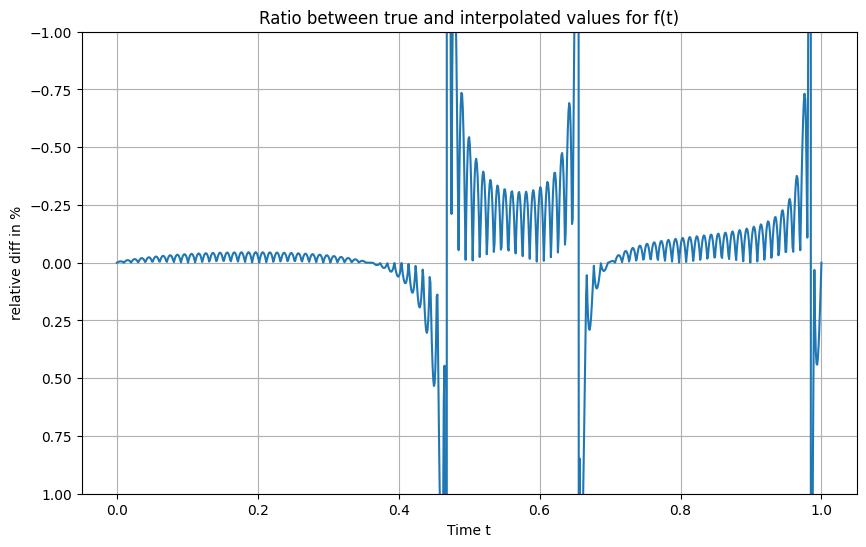

In [27]:
# Compute percent relative difference
ratio = 100*(f_pred - f_true)/f_true

plt.figure(figsize=(10, 6))
plt.plot(t_fine, ratio)
plt.xlabel("Time t")
plt.ylabel("relative diff in %")
plt.title("Ratio between true and interpolated values for f(t)")
plt.ylim(1, -1)   # match lecturer’s axis flip
plt.grid(True)
plt.show()


# Question 5

## Notes:
How does increasing a affect the function f(t;a)?
- By increasing a -> we increase the length of the peak/troughs of the curve. Technical definition is we increase the amplitude of the sin curves.
- A does not affect the frequency and does not move the curves left or right. Just up and down of the magnitude of the peaks.
- When a = 0, the function just dissolves to 0.5 * cos (2t) because sqrt(0) = 0

Why do we work with DataFrame than Numpy Array?
- Because we can store multiple different datatypes in a Pandas DataFrame compared to a NumPy array.

In [12]:
dataset = {0.9: "abc", "def": 789}
dataset_dataframe = pd.DataFrame(dataset, index = [6, 9])
dataset_dataframe

,0.9,def
6,abc,789
9,abc,789


         a=0.00    a=0.11    a=0.22    a=0.33    a=0.44    a=0.56    a=0.67  \
0.000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000  0.500000   
0.001  0.499999  0.502999  0.504242  0.505196  0.506000  0.506708  0.507348   
0.002  0.499996  0.505997  0.508483  0.510390  0.511998  0.513415  0.514696   
0.003  0.499991  0.508993  0.512722  0.515584  0.517996  0.520121  0.522042   
0.004  0.499984  0.511988  0.516960  0.520775  0.523991  0.526825  0.529387   
...         ...       ...       ...       ...       ...       ...       ...   
0.996 -0.204430 -0.035726  0.034153  0.087774  0.132978  0.172803  0.208808   
0.997 -0.205342 -0.039682  0.028937  0.081590  0.125978  0.165085  0.200440   
0.998 -0.206253 -0.043651  0.023701  0.075381  0.118951  0.157336  0.192038   
0.999 -0.207164 -0.047634  0.018446  0.069150  0.111896  0.149556  0.183603   
1.000 -0.208073 -0.051629  0.013172  0.062896  0.104815  0.141746  0.175135   

         a=0.78    a=0.89    a=1.00  
0.000  0.5000

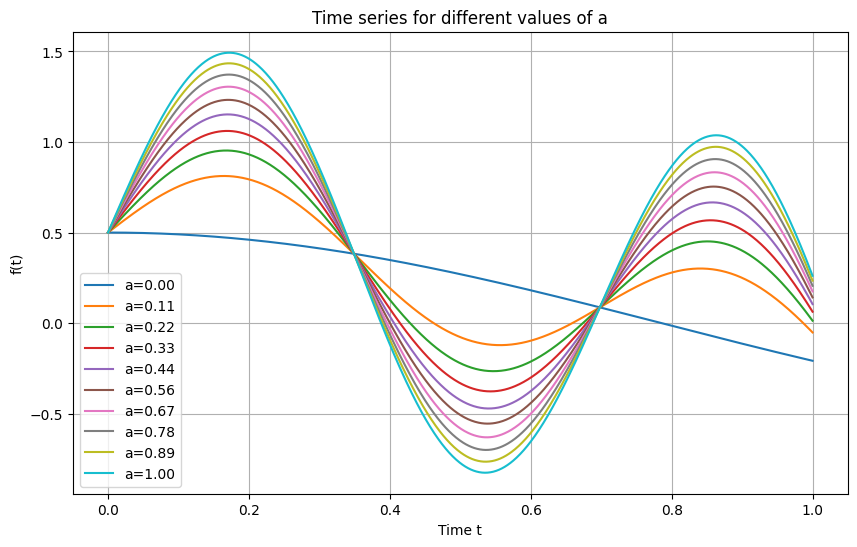

In [11]:
import pandas as pd
# Redefine the function because I did a lot of experimenting
def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b * t) * np.sin(c * t) + 0.5 * np.cos(2 * t)

# fixed parameters as the question asked
b = -0.13
c = 9

# time grid between 0 and 1 with 1001 intervals
t = np.linspace(0, 1, 1001)

# a values
a_values = np.linspace(0, 1, 10)

# compute all time series
data = {}
for a in a_values:
    data[f"a={a:.2f}"] = f(t, a, b, c)

# DataFrame
df = pd.DataFrame(data, index=t)
print(df)
df.index.name = "t"

# Plot
df.plot(figsize=(10,6), title="Time series for different values of a")
plt.xlabel("Time t")
plt.ylabel("f(t)")
plt.grid(True)
plt.show()

# Question 6

## Notes:
Question 6 wants us to interpolate over a and t just like we did in Q3. We should also plot the graph like Q4.
- This means instead of taking interp1d in one dimension, we are going 2D!
- We got two variables a and t to interpolate over.
- We need to use `RegularGridInterpolator` from SciPy which gives us interpolation in the mutli-dimensions.
- The question asked us to fix a at 0.125, it's like taking one of the above lines and then interpolating in 2D.
- This interpolator takes in two dimensions (a,t) if we wanted to evaluate for a=0.125 and a=0.7, we would union the column stack so a 0.125 and then underneath all the points for a 0.7

How do we interpret the percent relative error?
- This is the percent relative error of a 2 dimension function f(t and a)
- Between 0 and 0.3, the linear interpolation is good and stable in terms of the error, it's steady.
- Between 0.4, 0.6 and close to 1, the error explodes. Why? The denominator is the true value, and when the true value is close to 0 (the roots of f), the error explodes. Look at the first graph, you see that it's roots are close to 0.4,0.6 and 1. The error function shoots off! The absolute error (f_pred - f_true) is small but the relative is boom. 
- This is expected behaviour from relative errors, but the interpolator is good.
- Remember: relative error -> spikes -> f is close to 0.

Question for Andy:
- Why did we flip the percent relative error graph previously and now we are increasing the bounds of ylim to -4 and 4?
-- Because we would not be able to see the extra stuff on the graph. In the previous point for t =0.6, the error would be -1.25 whilst here when we are interpreting in 2D, the value of error is -2.

The column stacked pairs of a and t follow:
[[0.125      0.        ]
 [0.125      0.01010101]
 [0.125      0.02020202]
 [0.125      0.03030303]
 [0.125      0.04040404]
 [0.125      0.05050505]
 [0.125      0.06060606]
 [0.125      0.07070707]
 [0.125      0.08080808]
 [0.125      0.09090909]
 [0.125      0.1010101 ]
 [0.125      0.11111111]
 [0.125      0.12121212]
 [0.125      0.13131313]
 [0.125      0.14141414]
 [0.125      0.15151515]
 [0.125      0.16161616]
 [0.125      0.17171717]
 [0.125      0.18181818]
 [0.125      0.19191919]
 [0.125      0.2020202 ]
 [0.125      0.21212121]
 [0.125      0.22222222]
 [0.125      0.23232323]
 [0.125      0.24242424]
 [0.125      0.25252525]
 [0.125      0.26262626]
 [0.125      0.27272727]
 [0.125      0.28282828]
 [0.125      0.29292929]
 [0.125      0.3030303 ]
 [0.125      0.31313131]
 [0.125      0.32323232]
 [0.125      0.33333333]
 [0.125      0.34343434]
 [0.125      0.35353535]
 [0.125      0.36363636]
 [0.125      0.37373737]
 [0.12

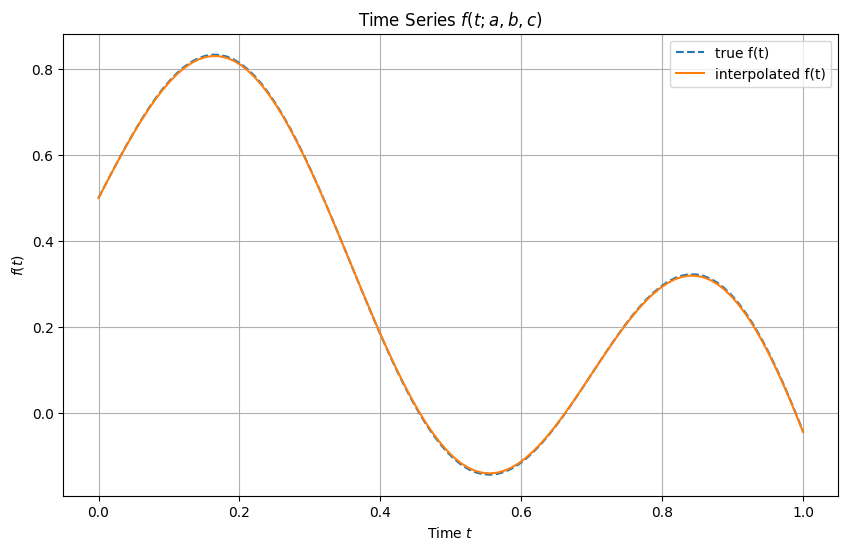

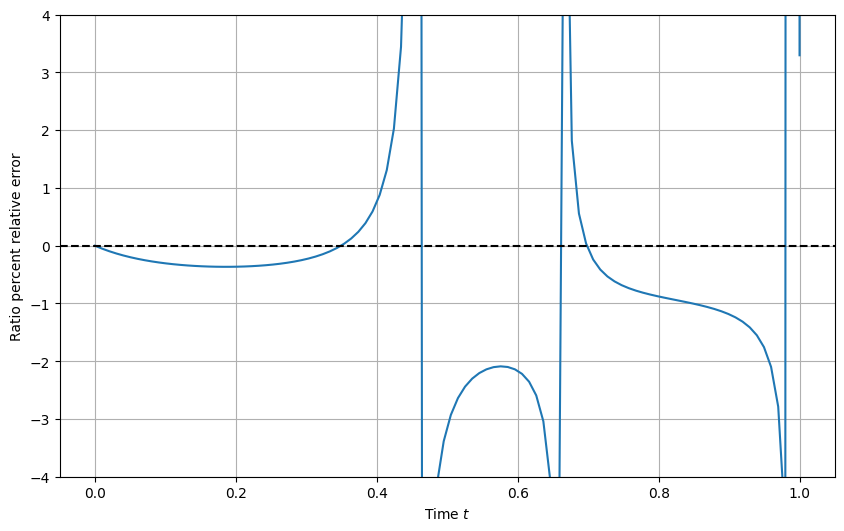

In [14]:
from scipy.interpolate import RegularGridInterpolator

# redefine the function f
def f(t, a, b, c):
    return np.sqrt(a) * np.exp(-b*t) * np.sin(c*t) + 0.5*np.cos(2*t)

# fixed parameters so we only use t and a in the linespace
b = -0.13
c = 9

# grids where a is 0 to 1 with 10 intervals. t is 0 to 1 with 100 intervals.
a_values = np.linspace(0, 1, 10)
t_values = np.linspace(0, 1, 100)

# compute F(a_i, t_j) by looping over the 10 values in a
F = np.zeros((len(a_values), len(t_values)))
for i, a in enumerate(a_values):
    F[i,:] = f(t_values, a, b, c)

# build interpolator over (a, t)
interp = RegularGridInterpolator(
    (a_values, t_values),
    F,
    method="linear"
)

# choose target a
a_target = 0.125
t_fine = np.linspace(0, 1, 100)

# evaluate interpolator
# we use column stack to give the interpolation what it needs
# interpolator needs pairs to be fed in (a,t),(a,t)...
# using column stack, we can create those pairs just like an array
pts = np.column_stack([np.full_like(t_fine, a_target), t_fine])
print("The column stacked pairs of a and t follow:")
print(pts)
f_pred = interp(pts)

# true function
f_true = f(t_fine, a_target, b, c)

# plot like Q3
plt.figure(figsize=(10,6))
plt.xlabel('Time $t$')
plt.ylabel(r'$f(t)$')
plt.title(r'Time Series $f(t; a, b, c)$')
plt.plot(t_fine, f_true, '--', label="true f(t)")
plt.plot(t_fine, f_pred, label="interpolated f(t)")
plt.legend(); plt.grid(True); plt.show()

# ratio like Q4
r = 100 * (f_pred - f_true) / f_true
plt.figure(figsize=(10,6))
plt.xlabel('Time $t$')
plt.ylabel('Ratio percent relative error')
plt.plot(t_fine, r)
plt.axhline(0, color='black', linestyle='--')
plt.ylim(-4, 4)
plt.grid(True)
plt.show()


Why does absolute error behave nicely, but relative error explodes?
- Because absolute error does not divide by a number that can be near zero.

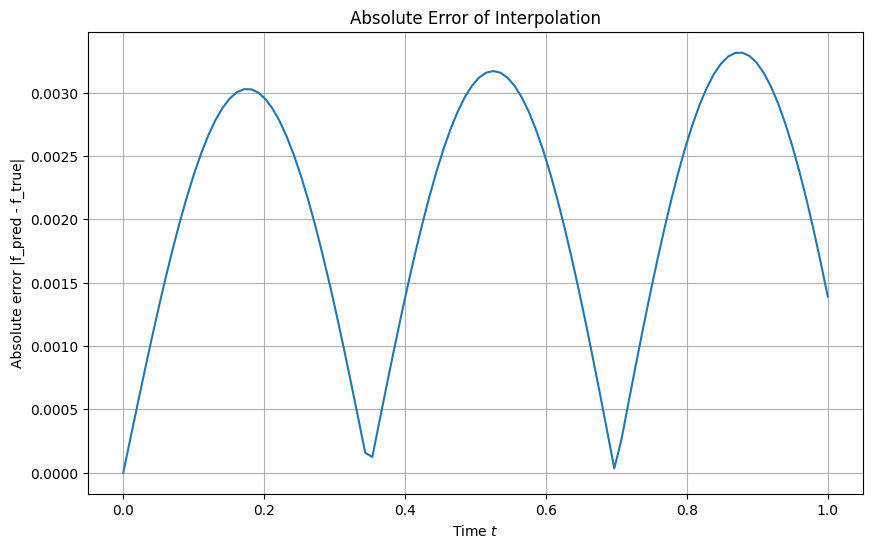

In [15]:
# Absolute error
abs_err = np.abs(f_pred - f_true)

plt.figure(figsize=(10, 6))
plt.plot(t_fine, abs_err)
plt.xlabel("Time $t$")
plt.ylabel("Absolute error |f_pred - f_true|")
plt.title("Absolute Error of Interpolation")
plt.grid(True)
plt.show()


# Question 7 and 8

## Notes:
Why was the original grid evaluated here rather than the fine grid?
- Because we used the original linspace(0,1,100) in the original interpolation
- We see how well the original interpolator preserves the original sample
- This isolates error due to interpolating across a, not error due to refining t.

What are we doing here?
- We focused on looking at the t-interpolation error in one dimension. We worked out that having a finer sample of t when linspace(0,1,100) to linspace(0,1,1001) is far denser and more accurate because there is smaller line segements inbetween points.
- Now we introduced a as a variable. We want to see how a-interpoaltion error looks like. We hold t fixed to the same original grid of linspace(0,1,100) and we slide a around to measure the relative error.
- If we did not fix t to the original grid, we would be having a total error = t-interpolation error + a-interpolation error. Since, we would be sliding t and a around.

Answer to Question 8:
- When we slide a close to 0.125, the relative error is small. Like we saw in Q6. When we now move away from the value, the relative error explodes.
- This will naturally be the case because we are in a coarse (wide) linspace of 10 intervals for a. This means we have huge line segements and our interpolated predicition is not great.
- When we are close to a known point 0.125, we have small error.
- If we increased the grid space interval from 10 to 100, we would have more dense points for a and the linear interpolation would be smoother and closer to true.
- Three behaviours are shown in the graph:
1) When a is close to known points like 0.125, the error term is small because it is a known point.
2) When a is away from the known point, the error increases. This is due to the coarse grid size of 10.
3) When a is very far away, the error explodes. We saw previously, explosions happen when the function crosses 0 (near it's roots).


In [ ]:
import ipywidgets as widgets
from ipywidgets import interact


t_orig = np.linspace(0, 1, 100)   # your original interpolation grid
def plot_ratio(a):
    # predicted values from 2D interpolator on the original t-grid
    pts = np.column_stack([np.full_like(t_orig, a), t_orig])
    f_pred = interp(pts)

    # true function values
    f_true = f(t_orig, a, b, c)

    # compute relative error (percent)
    r = 100 * (f_pred / f_true - 1)

    # plot
    plt.figure(figsize=(10, 6))
    plt.plot(t_orig, r)
    plt.axhline(0, color='black', linestyle='--')
    plt.xlabel("Time t")
    plt.ylabel("Percent relative error (%)")
    plt.title(f"Relative Error for a = {a:.3f}")
    plt.grid(True)
    plt.ylim(-10, 10)   # adjust based on spike height
    plt.show()


interact(plot_ratio, a=widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01))


interactive(children=(FloatSlider(value=0.5, description='a', max=1.0, step=0.01), Output()), _dom_classes=('w…

<function __main__.plot_ratio(a)>

## Class Notes

sqrt(a) is in the original function. When a gets bigger, the derivate gets smaller.

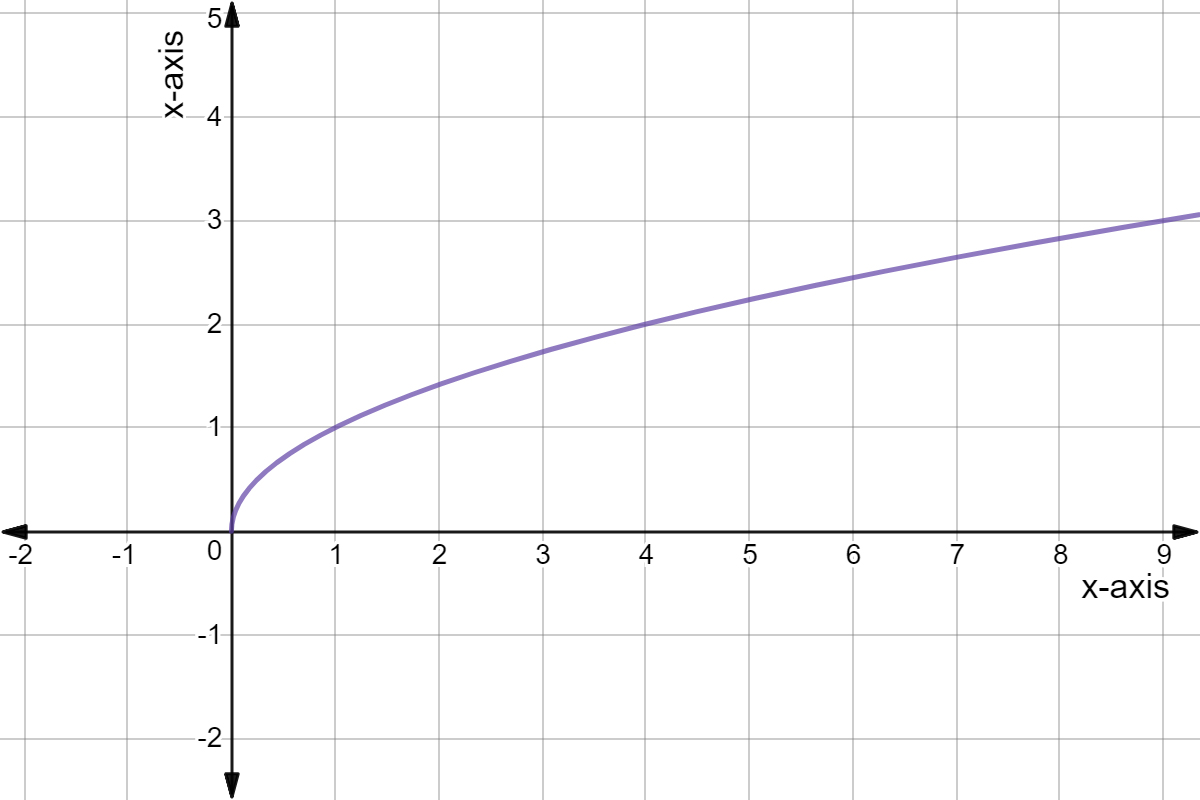


# Question 9

(0.0, 1.0)

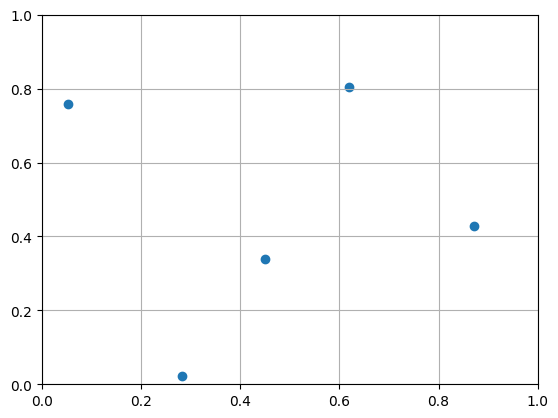

In [20]:
#%pip install pyDOE
from pyDOE import lhs

latin_hyper_cube = lhs(2, samples=5)#, criterion = 'c')
plt.scatter(latin_hyper_cube[:, 0], latin_hyper_cube[:,1])
plt.grid(True)
plt.xlim([0,1])
plt.ylim([0,1])

A 5x5 grid. Latin Hyper Cube is a subset of the grid. The subsets are the blue dots. If you take any row or any column, it takes has one subset. Take column 3, boom one subset. Row 2, boom one subset.
The subset means, there is a 5x5 grid = 25 boxes. Latin hyper cube only takes 5 boxes but has the special property that it's subset is in any row or column.

In [21]:
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from pyDOE import lhs  # For Latin Hypercube Sampling

# Define the ranges for `a`, `b`, and `t`
t = np.linspace(0, 1, 100)  # Time range with 100 points
a_range = (0., 1.0)
b_range = (-0.5, 0.5)

# Generate Latin Hypercube samples for `a` and `b`
n_samples = 100  # Define the number of samples for each parameter
lhs_samples = lhs(2, samples=n_samples)  # Latin Hypercube sampling in 2D



# Scale the samples to the range of `a` and `b`
a_values = a_range[0] + lhs_samples[:, 0] * (a_range[1] - a_range[0])
b_values = b_range[0] + lhs_samples[:, 1] * (b_range[1] - b_range[0])


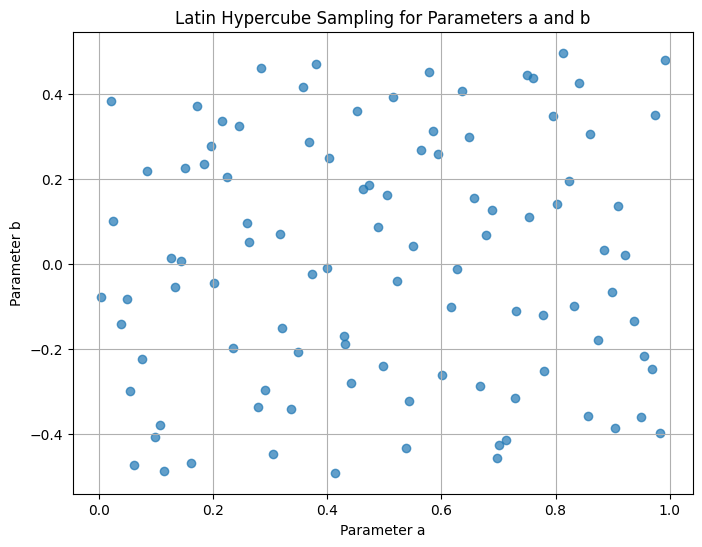

In [22]:
# Plot the Latin Hypercube samples as a 2D scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(a_values, b_values, alpha=0.7)
plt.xlabel("Parameter a")
plt.ylabel("Parameter b")
plt.title("Latin Hypercube Sampling for Parameters a and b")
plt.grid(True)
plt.show()

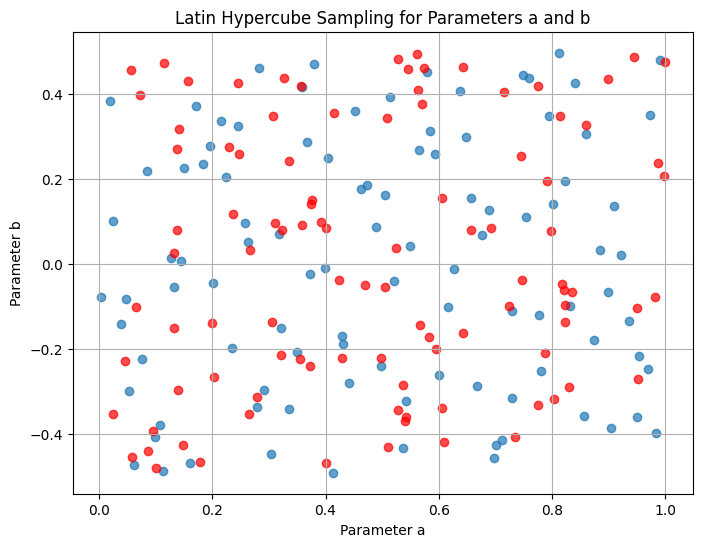

In [23]:
# Generate uniformly sampled values for `a` and `b`
ua_values = np.random.uniform(a_range[0], a_range[1], n_samples)
ub_values = np.random.uniform(b_range[0], b_range[1], n_samples)

# Plot the Latin Hypercube samples as a 2D scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(a_values, b_values, alpha=0.7)
plt.scatter(ua_values, ub_values, alpha=0.7,c='r')
plt.xlabel("Parameter a")
plt.ylabel("Parameter b")
plt.title("Latin Hypercube Sampling for Parameters a and b")
plt.grid(True)
plt.show()

There are some clusters of the red points but not so with the blue points

# Question 11

Create the interpolator over the parameter space (a,b), interpolating over samples of the function evaluated at the original time grid t

As you will realise, we are dealing with an irregular grid and need the griddata method (doc).

In [24]:
t = np.linspace(0, 1, 100)  # Time range with 100 points, always fixed

from scipy.interpolate import griddata
# Generate function samples for each (a, b) pair over time `t`
# Create lists to hold points and values for interpolation
points = []  # Will store (t, a, b) tuples
values = []  # Will store corresponding f(t, a, b, c) values

for a, b in zip(a_values, b_values):
    for time in t:
        points.append((time, a, b))
        values.append(f(time, a, b, c))  # Replace `f` with your actual function definition

# Convert lists to NumPy arrays for griddata use
points = np.array(points)  # Shape: (len(t) * n_samples, 3)
values = np.array(values)  # Shape: (len(t) * n_samples,)

# Define a function to interpolate over new values of `a` and `b` using griddata
def interpolate_f_over_a_b(tgrid, new_a, new_b):
    # Create an array of (time, new_a, new_b) points to interpolate
    query_points = np.array([(time, new_a, new_b) for time in tgrid])

    # Use griddata to interpolate the function at the given points
    interpolated_values = griddata(points, values, query_points, method='linear')
    return interpolated_values


## Class Notes
1. `zip` is a great tool to create a tuple

In [26]:
for a,b in zip([1,2,3],[4,5,6]):
    print(f"value of a: {a}, value of b: {b}")

value of a: 1, value of b: 4
value of a: 2, value of b: 5
value of a: 3, value of b: 6


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets

tn = np.linspace(0, 1, 100)

# Define the interpolator function for dynamic plotting
def plot_with_interpolated_values(ap, bp):
    # Original function values for given `a` and `b`
    original_values = f(tn, ap, bp, c)  # Replace `f` with your actual function definition

    # Interpolated values for the given `a` and `b`
    # interpolated_values = interpolator([(time, ap, bp) for time in tn])
    interpolated_values = interpolate_f_over_a_b(tn, ap, bp)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(tn, original_values, label=r'$f(t; a, b)$', color='blue',ls='None',marker='o')
    plt.plot(tn, interpolated_values, label=r'$F_{interp}(t)$', color='red', linestyle='None',marker='o')
    plt.xlabel('Time $t$')
    plt.ylabel(r'$f(t)$')
    plt.title(r'Time Series $f(t; a, b)$')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define sliders for `a` and `b`
a_slider = FloatSlider(value=0.125, min=0.0, max=1.0, step=0.01, description='a')
b_slider = FloatSlider(value=0.0, min=-0.5, max=0.5, step=0.01, description='b')

# Use `interact` to create the interactive plot
interact(plot_with_interpolated_values, ap=a_slider, bp=b_slider)


interactive(children=(FloatSlider(value=0.125, description='a', max=1.0, step=0.01), FloatSlider(value=0.0, de…

<function __main__.plot_with_interpolated_values(ap, bp)>

In [ ]:
# Define the interpolator function for dynamic plotting
def plot_with_interpolated_values(ap, bp):
    # Original function values for given `a` and `b`
    original_values = f(tn, ap, bp, c)  # Replace `f` with your actual function definition

    # Interpolated values for the given `a` and `b`
    interpolated_values = interpolate_f_over_a_b(tn, ap, bp)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(tn, 100*(interpolated_values-original_values)/original_values, label=r'relative difference', color='red', linestyle='--')
    plt.xlabel('Time $t$')
    plt.ylabel(r'rel diff %')
    plt.title(r'Time Series $f(t; a, b, c)$')
    plt.legend()
    plt.ylim(-2,2)
    plt.grid(True)
    plt.show()

# Define sliders for `a` and `b`
a_slider = FloatSlider(value=0.125, min=0.0, max=1.0, step=0.01, description='a')
b_slider = FloatSlider(value=0.0, min=-0.5, max=0.5, step=0.01, description='b')

# Use `interact` to create the interactive plot
interact(plot_with_interpolated_values, ap=a_slider, bp=b_slider)

interactive(children=(FloatSlider(value=0.125, description='a', max=1.0, step=0.01), FloatSlider(value=0.0, de…

<function __main__.plot_with_interpolated_values(ap, bp)>

Interpolation is now even harder (memory, accurracy, compute time, etc) and much less accurate. We start to see the real effects of curse of dimensionality!

# Question 13

Compare memory and time of (i) the original function call and (ii) the interpolator call.

Comment. Numbers make sense, with respect to what we explain about curse of dimensionality!

In [29]:
import numpy as np
import tracemalloc
import timeit

# Define the time array `tn`
tn = np.linspace(0, 1, 100)  # Increase number of points for the test
ap = 0.125  # Fixed values for parameters
bp = 0.1
c, d, e = 1.0, 1.0, 1.0  # Fixed parameters for `f`

# Define a wrapper function to measure the original function call
def original_function_call():
    return f(tn, ap, bp, c)  # Replace `f` with your actual function definition

# Define a wrapper function to measure the interpolator call
def interpolator_call():
    return interpolate_f_over_a_b(tn, ap, bp)

# Measure time
time_original = timeit.timeit(original_function_call, number=10)
time_interpolator = timeit.timeit(interpolator_call, number=10)

# Measure memory using tracemalloc
def measure_memory(func):
    tracemalloc.start()
    func()  # Run the function to allocate memory
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return peak / (1024 * 1024)  # Memory in MB

memory_original = measure_memory(original_function_call)
memory_interpolator = measure_memory(interpolator_call)

# Print results
print(f"Original function call time (10 runs): {time_original:.4f} seconds")
print(f"Interpolator call time (10 runs): {time_interpolator:.4f} seconds")
print(f"Original function call memory usage: {memory_original:.4f} MB")
print(f"Interpolator call memory usage: {memory_interpolator:.4f} MB")

Original function call time (10 runs): 0.0002 seconds
Interpolator call time (10 runs): 3.6127 seconds
Original function call memory usage: 0.0027 MB
Interpolator call memory usage: 10.9009 MB


# Question 14

Add a third parameter, 
 to our interpolation problem and repeat questions 9 to 13.

For this parameter, use a range of 
.

Comment on the results.

In [30]:
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
from pyDOE import lhs  # For Latin Hypercube Sampling

# Define the ranges for `a`, `b`, and `t`
t = np.linspace(0, 1, 100)  # Time range with 100 points
a_range = (0., 1.0)
b_range = (-0.5, 0.5)
c_range = (5, 10)

# Generate Latin Hypercube samples for `a` and `b`
n_samples = 100  # Define the number of samples for each parameter
lhs_samples = lhs(3, samples=n_samples)  # Latin Hypercube sampling in 2D



# Scale the samples to the range of `a` and `b`
a_values = a_range[0] + lhs_samples[:, 0] * (a_range[1] - a_range[0])
b_values = b_range[0] + lhs_samples[:, 1] * (b_range[1] - b_range[0])
c_values = c_range[0] + lhs_samples[:, 2] * (c_range[1] - c_range[0])

Text(0.5, 0.92, '3D Latin Hypercube Sampling for Parameters a, b, and c')

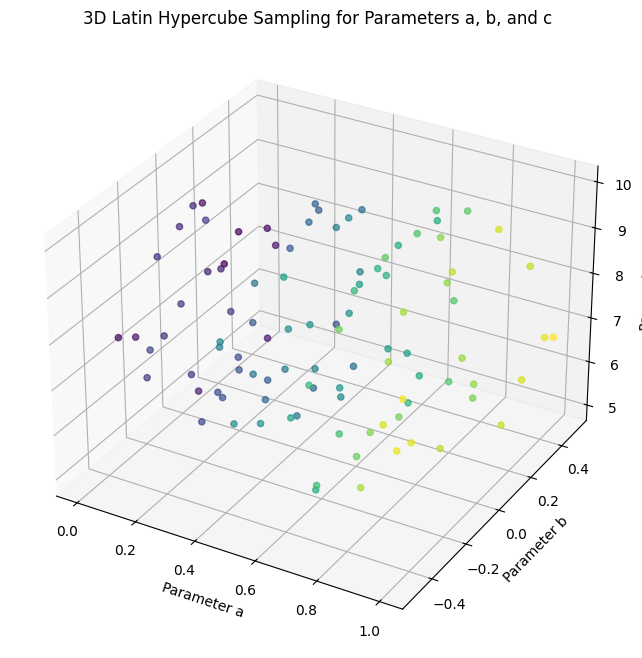

In [31]:
# Plot the Latin Hypercube samples in 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(a_values, b_values, c_values, c=a_values, cmap='viridis', marker='o', alpha=0.7)

# Set plot labels and title
ax.set_xlabel('Parameter a')
ax.set_ylabel('Parameter b')
ax.set_zlabel('Parameter c')
ax.set_title('3D Latin Hypercube Sampling for Parameters a, b, and c')